<a href="https://colab.research.google.com/github/wagino89/for-paper-ME-XBal/blob/main/tokopedia_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ME-XBAL (Multilingual Emotion eXplainable BALancer)

In [ ]:
# ==========================================
# 🔬 TOKOPEDIA EMOTION DATASET (SINGLE LABEL)
# ==========================================
import pandas as pd
import numpy as np
import torch
import joblib
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ==========================================
# 1. LOAD DATASET
# ==========================================
df = pd.read_csv('https://drive.google.com/uc?id=1KCf-ma9eobRRzERzGso_CRR3-FXU1x4h')

print("Columns:", df.columns)
print(df.head())

# Sesuaikan nama kolom
text_col = "Customer Review"
label_col = "Emotion"

# Drop missing
df = df[[text_col, label_col]].dropna()

# ==========================================
# 2. LABEL ENCODING
# ==========================================
le = LabelEncoder()
df['label'] = le.fit_transform(df[label_col])

print("\nClasses:", le.classes_)

# ==========================================
# 3. TRAIN TEST SPLIT
# ==========================================
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

y_train = df_train['label'].values
y_test  = df_test['label'].values

# ==========================================
# 4. LOAD XLM-R
# ==========================================
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# ==========================================
# 5. EMBEDDING FUNCTION
# ==========================================
def extract_embeddings(texts, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls)

    return np.vstack(embeddings)

# ==========================================
# 6. FEATURE EXTRACTION
# ==========================================
print("\n🔄 Extracting embeddings...")
X_train = extract_embeddings(df_train[text_col].astype(str).tolist())
X_test  = extract_embeddings(df_test[text_col].astype(str).tolist())

# ==========================================
# 7. PREPROCESSING
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("\nReduced dim:", X_train_pca.shape[1])

# ==========================================
# 8. TRAIN MODELS
# ==========================================
num_classes = len(le.classes_)

# XGBoost
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train_pca, y_train)

# Logistic Regression
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_pca, y_train)

# ==========================================
# 9. PREDICTION (HYBRID)
# ==========================================
xgb_proba = xgb_model.predict_proba(X_test_pca)
lr_proba  = lr_model.predict_proba(X_test_pca)

hybrid_proba = 0.7 * xgb_proba + 0.3 * lr_proba
y_pred = np.argmax(hybrid_proba, axis=1)

# ==========================================
# 10. EVALUATION
# ==========================================
macro_f1 = f1_score(y_test, y_pred, average='macro')
micro_f1 = f1_score(y_test, y_pred, average='micro')
acc = accuracy_score(y_test, y_pred)

print("\n📊 RESULTS (TOKOPEDIA DATASET - SINGLE LABEL)")
print("="*60)
print(f"Macro F1 : {macro_f1:.4f}")
print(f"Micro F1 : {micro_f1:.4f}")
print(f"Accuracy : {acc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(le.classes_)),
    target_names=le.classes_,
    zero_division=0
))

Columns: Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='object')
                Category                                       Product Name  \
0  Computers and Laptops  Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...   
1  Computers and Laptops  PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...   
2  Computers and Laptops                SSD Midasforce 128 Gb - Tanpa Caddy   
3  Computers and Laptops  ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...   
4  Computers and Laptops  ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...   

                 Location   Price  Overall Rating  Number Sold  Total Review  \
0           Jakarta Utara   53500             4.9         5449          2369   
1  Kota Tangerang Selatan   72000             4.9         2359          1044   
2           Jakarta Barat  213000             5.0        12300          

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🔄 Extracting embeddings...


100%|██████████| 34/34 [00:04<00:00,  7.53it/s]



Reduced dim: 116

📊 RESULTS (TOKOPEDIA DATASET - SINGLE LABEL)
Macro F1 : 0.5397
Micro F1 : 0.5880
Accuracy : 0.5880

📋 Classification Report:
              precision    recall  f1-score   support

       Anger       0.48      0.36      0.41       140
        Fear       0.42      0.35      0.38       184
       Happy       0.72      0.81      0.76       354
        Love       0.66      0.54      0.59       162
     Sadness       0.50      0.60      0.55       240

    accuracy                           0.59      1080
   macro avg       0.56      0.53      0.54      1080
weighted avg       0.58      0.59      0.58      1080



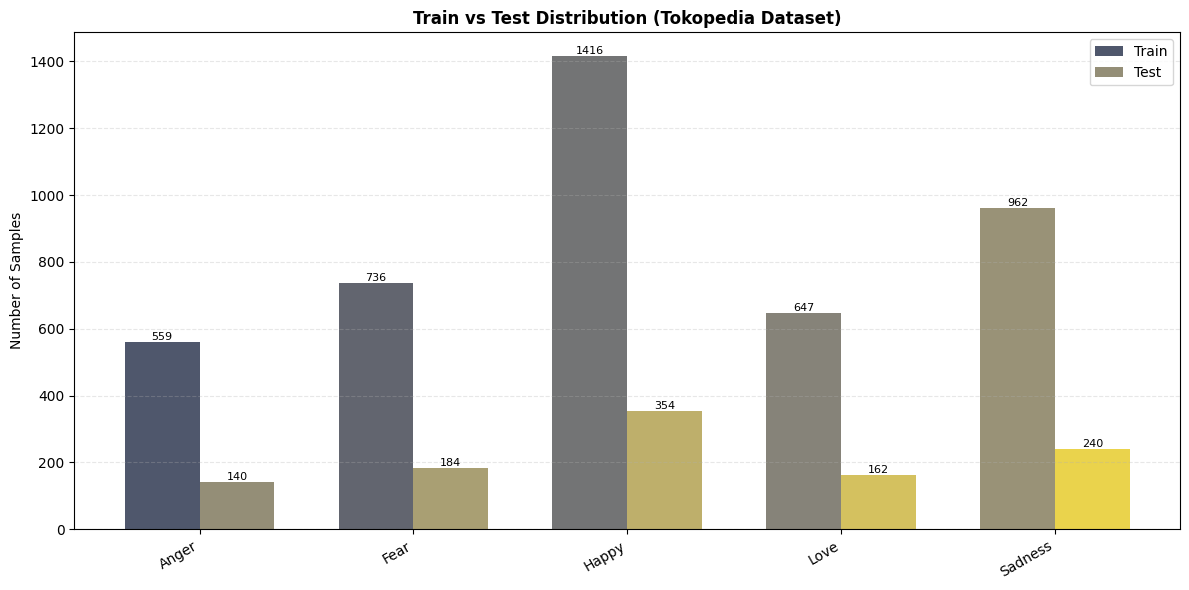

In [ ]:
# ==========================================
# 📊 TRAIN vs TEST DISTRIBUTION (CIVIDIS)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# ================================
# HITUNG DISTRIBUSI
# ================================
train_counts = df_train['label'].value_counts().sort_index()
test_counts  = df_test['label'].value_counts().sort_index()

labels = le.classes_

# ================================
# POSISI BAR
# ================================
x = np.arange(len(labels))
width = 0.35

# ================================
# WARNA CIVIDIS
# ================================
cmap = plt.cm.cividis
colors_train = [cmap(0.3 + 0.4*i/len(labels)) for i in range(len(labels))]
colors_test  = [cmap(0.6 + 0.4*i/len(labels)) for i in range(len(labels))]

# ================================
# PLOT
# ================================
plt.figure(figsize=(12,6))

bars1 = plt.bar(x - width/2, train_counts, width,
                label='Train', color=colors_train)

bars2 = plt.bar(x + width/2, test_counts, width,
                label='Test', color=colors_test)

# ================================
# LABEL ANGKA
# ================================
for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h,
             f'{int(h)}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h,
             f'{int(h)}', ha='center', va='bottom', fontsize=8)

# ================================
# LABEL & TITLE
# ================================
plt.xticks(x, labels, rotation=30, ha='right')
plt.ylabel("Number of Samples")
plt.title("Train vs Test Distribution (Tokopedia Dataset)", fontweight='bold')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

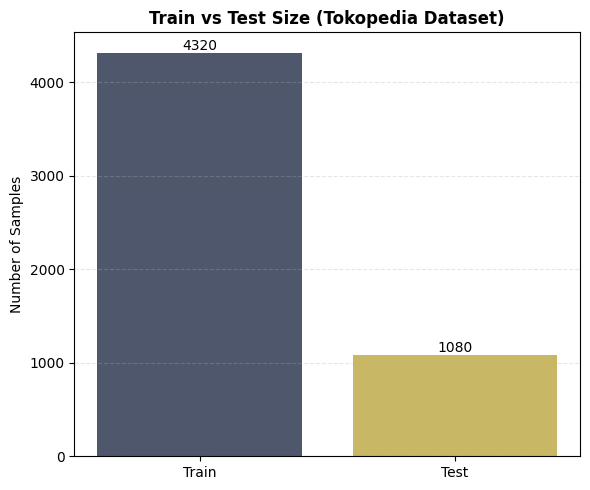

In [ ]:
# ==========================================
# 📊 TOTAL TRAIN vs TEST DISTRIBUTION
# ==========================================
import matplotlib.pyplot as plt

# ================================
# HITUNG TOTAL
# ================================
train_total = len(df_train)
test_total  = len(df_test)

labels = ['Train', 'Test']
values = [train_total, test_total]

# ================================
# WARNA CIVIDIS
# ================================
cmap = plt.cm.cividis
colors = [cmap(0.3), cmap(0.8)]

# ================================
# PLOT
# ================================
plt.figure(figsize=(6, 5))

bars = plt.bar(labels, values, color=colors)

# ================================
# LABEL ANGKA
# ================================
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height}",
        ha='center',
        va='bottom',
        fontsize=10
    )

# ================================
# LABEL & TITLE
# ================================
plt.ylabel("Number of Samples")
plt.title("Train vs Test Size (Tokopedia Dataset)", fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrix Per Emotion

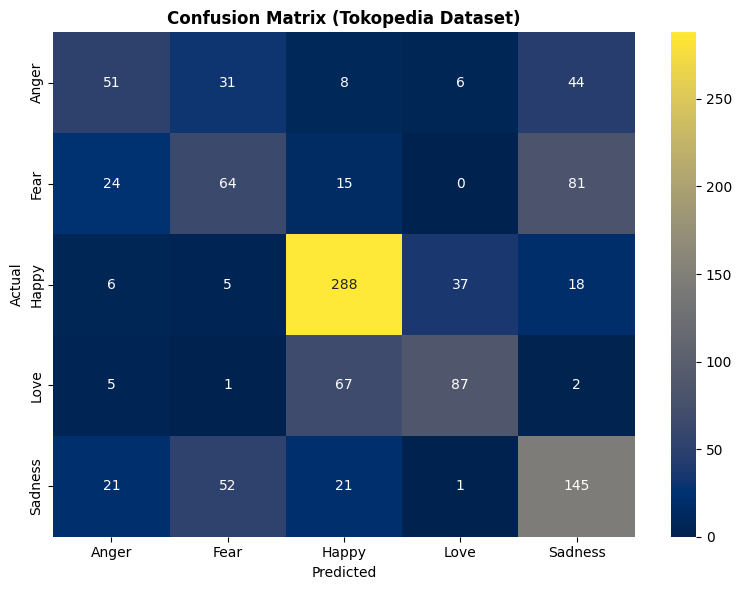

In [ ]:
# ==========================================
# 📊 CONFUSION MATRIX (TOKOPEDIA)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ================================
# 1. CONFUSION MATRIX (MULTI-CLASS)
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='cividis',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Tokopedia Dataset)", fontweight='bold')
plt.tight_layout()
plt.show()

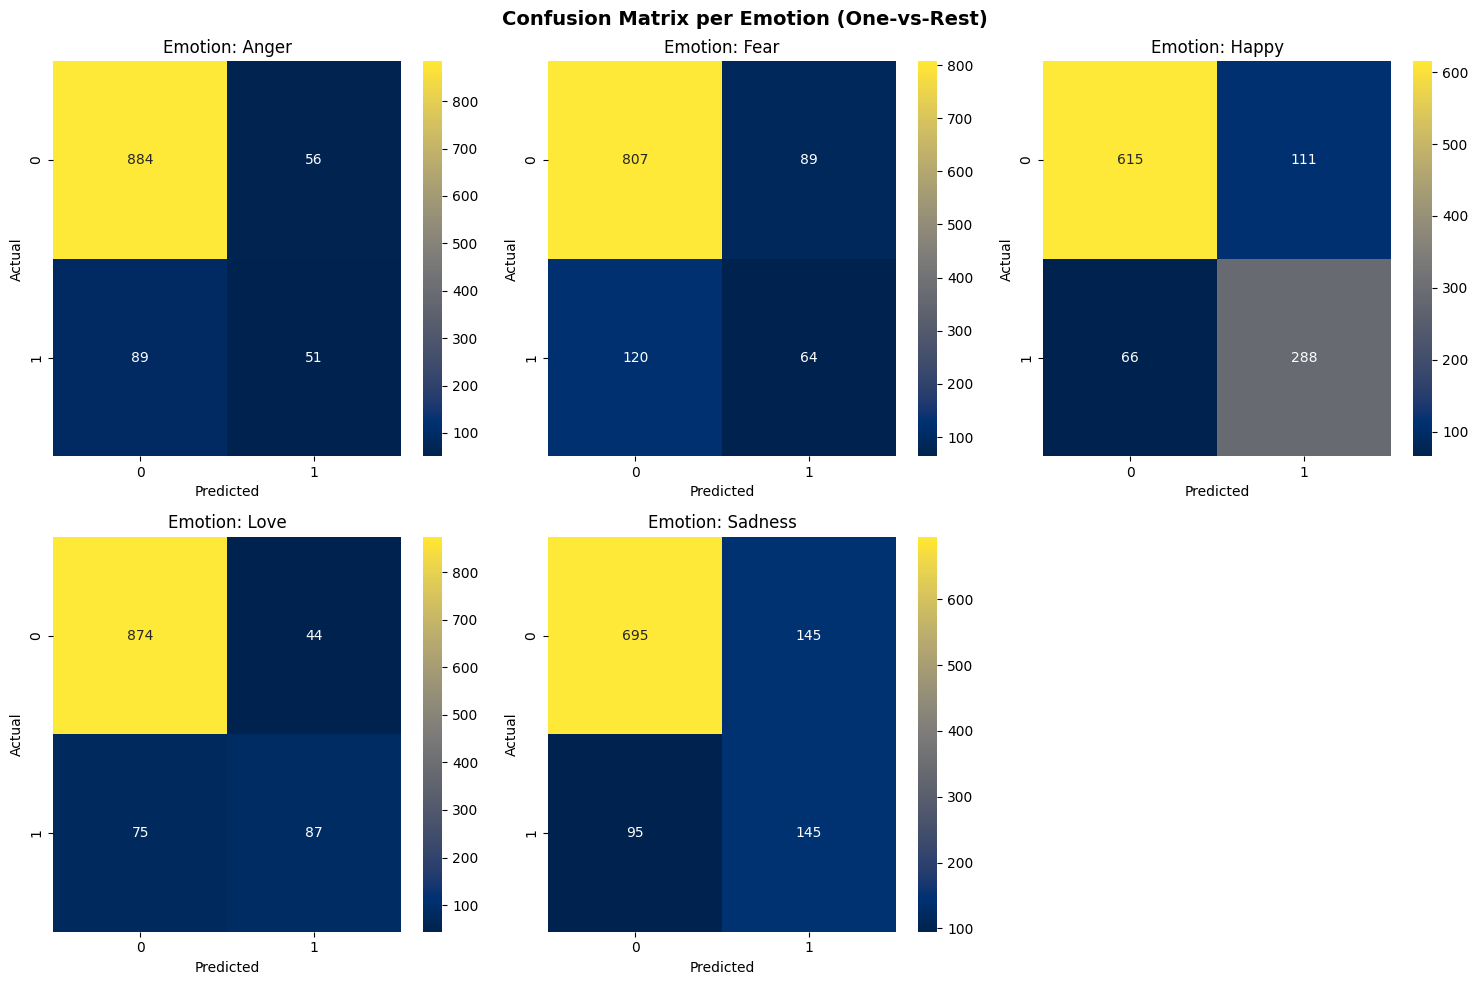

In [ ]:
# ==========================================
# 📊 CONFUSION MATRIX PER EMOTION
# ==========================================
num_classes = len(le.classes_)

fig, axes = plt.subplots(
    int(np.ceil(num_classes / 3)),
    3,
    figsize=(15, 5 * int(np.ceil(num_classes / 3)))
)

axes = axes.flatten()

for i in range(num_classes):

    # ubah ke binary (one-vs-rest)
    y_true_bin = (y_test == i).astype(int)
    y_pred_bin = (y_pred == i).astype(int)

    cm = confusion_matrix(y_true_bin, y_pred_bin)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='cividis',
        ax=axes[i]
    )

    axes[i].set_title(f"Emotion: {le.classes_[i]}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# hapus subplot kosong
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Confusion Matrix per Emotion (One-vs-Rest)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

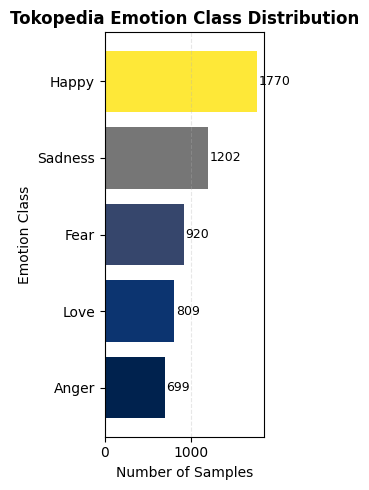

In [ ]:
# ==========================================
# 📊 TOKOPEDIA CLASS DISTRIBUTION
# (HORIZONTAL BAR CHART)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# ================================
# COUNT LABELS
# ================================
class_counts = df[label_col].value_counts()

labels = class_counts.index.tolist()
values = class_counts.values.tolist()

# ================================
# SORT (OPTIONAL)
# ================================
sorted_idx = np.argsort(values)

labels = [labels[i] for i in sorted_idx]
values = [values[i] for i in sorted_idx]

# ================================
# CIVIDIS COLORS
# ================================
cmap = plt.cm.cividis

norm = (
    (np.array(values) - np.min(values))
    / (np.max(values) - np.min(values))
)

colors = [cmap(n) for n in norm]

# ================================
# PLOT
# ================================
plt.figure(figsize=(3,5))

bars = plt.barh(
    labels,
    values,
    color=colors
)

# ================================
# VALUE LABELS
# ================================
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        fontsize=9
    )

# ================================
# LABELS & TITLE
# ================================
plt.xlabel("Number of Samples")
plt.ylabel("Emotion Class")

plt.title(
    "Tokopedia Emotion Class Distribution",
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Explainability Using SHAP

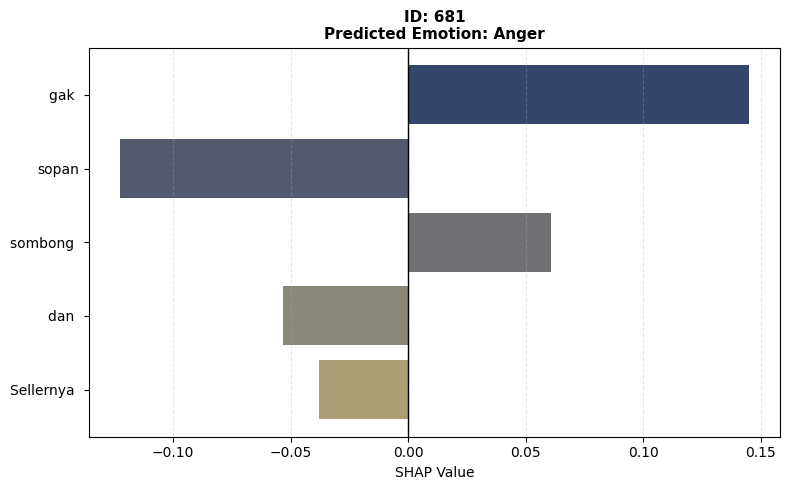

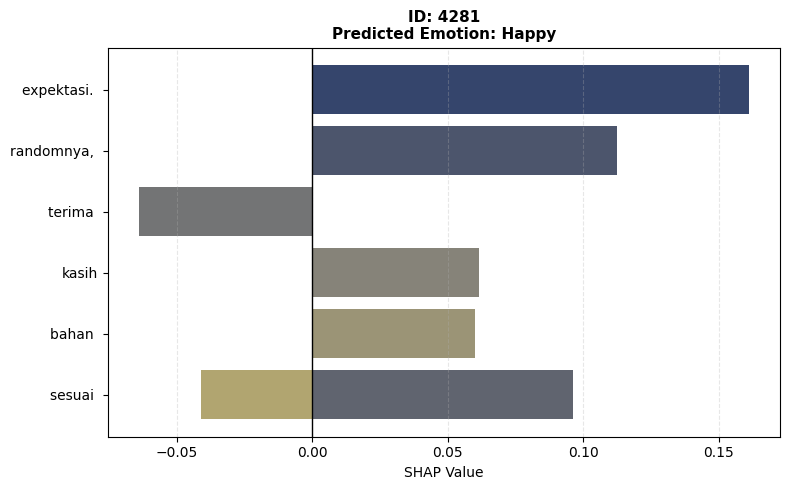

  0%|          | 0/498 [00:00<?, ?it/s]

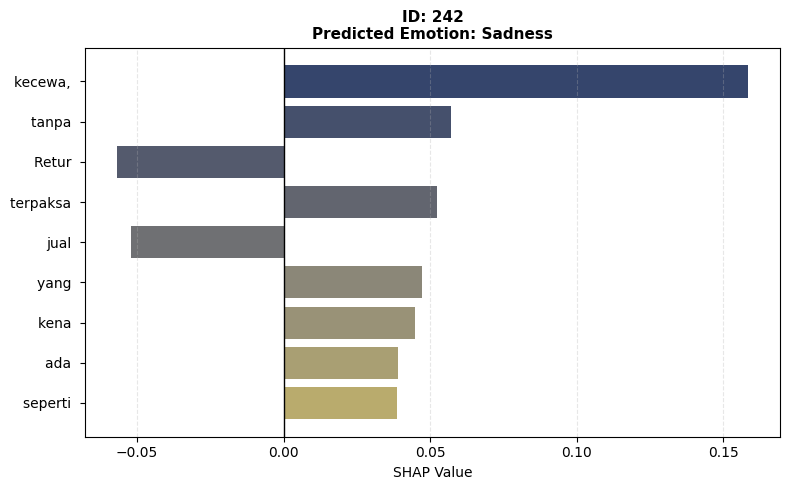

In [ ]:
# ==========================================
# 🔍 SHAP EXPLAINABILITY (TOKOPEDIA - SINGLE LABEL)
# ==========================================
import shap
import numpy as np
import matplotlib.pyplot as plt

shap.initjs()

# ================================
# AMBIL SAMPLE DARI TEST SET
# ================================
samples = [
    ("Indonesia", df_test.iloc[0]),
    ("Indonesia", df_test.iloc[1]),
    ("Indonesia", df_test.iloc[2])
]

# ================================
# MASKER (WORD-LEVEL)
# ================================
masker = shap.maskers.Text(r"\W+")

# ================================
# FUNCTION: PREDICT PROBA (MULTI-CLASS)
# ================================
def predict_proba_texts(texts):

    embeddings = []

    for text in texts:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_emb[0])

    X = np.vstack(embeddings)

    X_scaled = scaler.transform(X)
    X_pca = pca.transform(X_scaled)

    # gunakan hybrid (ME-XBAL style)
    xgb_proba = xgb_model.predict_proba(X_pca)
    lr_proba  = lr_model.predict_proba(X_pca)

    hybrid_proba = 0.7 * xgb_proba + 0.3 * lr_proba

    return hybrid_proba


# ================================
# LOOP SHAP
# ================================
for lang, row in samples:

    text = str(row[text_col])
    text_id = row.name  # index sebagai ID

    # ================================
    # PREDICTION
    # ================================
    probs = predict_proba_texts([text])[0]
    pred_idx = np.argmax(probs)
    pred_label = le.classes_[pred_idx]

    # ================================
    # SHAP (FOCUS KE 1 CLASS)
    # ================================
    explainer = shap.Explainer(
        lambda x: predict_proba_texts(x)[:, pred_idx],
        masker
    )

    shap_values = explainer([text])[0]

    words = shap_values.data
    scores = shap_values.values

    # ================================
    # CLEAN TOKEN
    # ================================
    words_clean = []
    scores_clean = []

    for w, s in zip(words, scores):
        if w.strip() != "":
            words_clean.append(w)
            scores_clean.append(s)

    # ================================
    # TOP WORDS
    # ================================
    idx_sorted = np.argsort(np.abs(scores_clean))[::-1][:10]

    words_plot = [words_clean[i] for i in idx_sorted]
    scores_plot = [scores_clean[i] for i in idx_sorted]

    # ================================
    # CIVIDIS COLORS
    # ================================
    cmap = plt.cm.cividis
    colors = [cmap(0.2 + 0.6*(i/len(words_plot))) for i in range(len(words_plot))]

    # ================================
    # PLOT
    # ================================
    plt.figure(figsize=(8, 5))

    plt.barh(words_plot[::-1], scores_plot[::-1], color=colors[::-1])
    plt.axvline(0, color='black', linewidth=1)

    plt.xlabel("SHAP Value")
    plt.title(
        f"ID: {text_id}\nPredicted Emotion: {pred_label}",
        fontsize=11,
        fontweight='bold'
    )

    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Ablation Study

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

🔄 Extracting embeddings...


100%|██████████| 34/34 [00:05<00:00,  6.78it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea


📊 RESULTS (TOKOPEDIA - ABLATION)
ME-XBAL             : 0.5569
XLM-R LR            : 0.5527
XLM-R XGB           : 0.5221
XLM-R Hybrid        : 0.5569
IndoBERT LR         : 0.5323
IndoBERT XGB        : 0.5098
IndoBERT Hybrid     : 0.5555


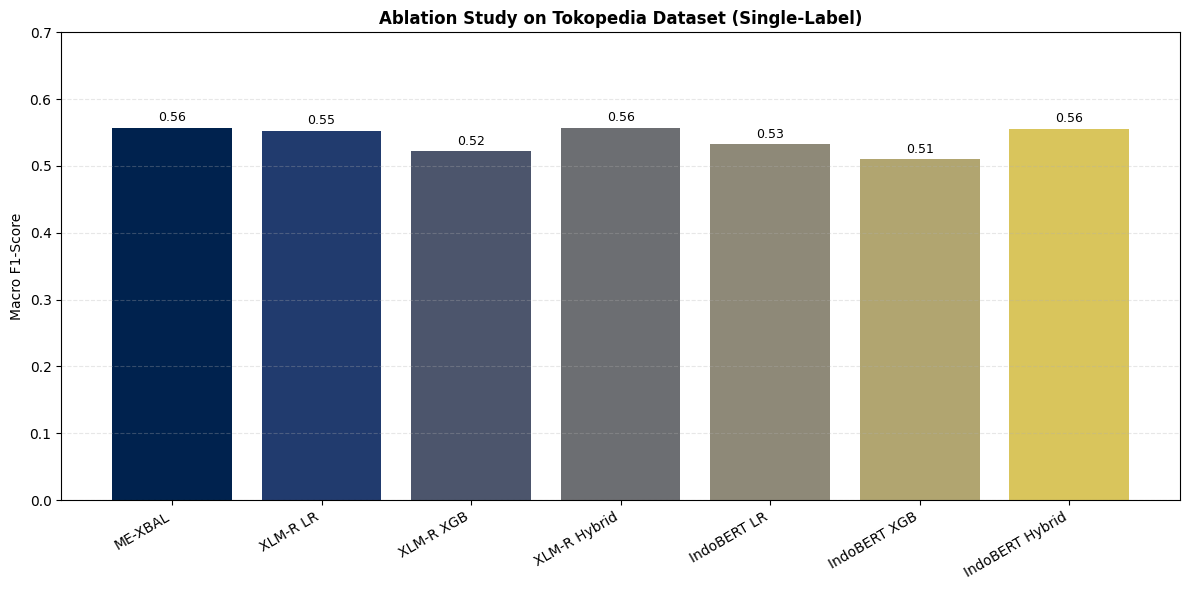

In [ ]:
# ==========================================
# 🔬 ABLATION STUDY - TOKOPEDIA DATASET
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm

# ================================
# LOAD TRANSFORMERS
# ================================
def load_model(name):
    tok = AutoTokenizer.from_pretrained(name)
    mod = AutoModel.from_pretrained(name)
    return tok, mod

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

xlmr_tok, xlmr_mod = load_model("xlm-roberta-base")
indo_tok, indo_mod = load_model("indobenchmark/indobert-base-p1")

xlmr_mod.to(device).eval()
indo_mod.to(device).eval()

# ================================
# EMBEDDING FUNCTION
# ================================
def extract(texts, tokenizer, model):
    out = []
    for i in tqdm(range(0, len(texts), 32)):
        batch = texts[i:i+32]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            out.append(cls)

    return np.vstack(out)

# ================================
# EXTRACT FEATURES
# ================================
print("🔄 Extracting embeddings...")

X_xlmr_train = extract(df_train[text_col].astype(str).tolist(), xlmr_tok, xlmr_mod)
X_xlmr_test  = extract(df_test[text_col].astype(str).tolist(), xlmr_tok, xlmr_mod)

X_indo_train = extract(df_train[text_col].astype(str).tolist(), indo_tok, indo_mod)
X_indo_test  = extract(df_test[text_col].astype(str).tolist(), indo_tok, indo_mod)

# ================================
# PREPROCESSING (reuse PCA & scaler)
# ================================
X_xlmr_train = pca.transform(scaler.transform(X_xlmr_train))
X_xlmr_test  = pca.transform(scaler.transform(X_xlmr_test))

X_indo_train = pca.transform(scaler.transform(X_indo_train))
X_indo_test  = pca.transform(scaler.transform(X_indo_test))

# ================================
# TRAIN FUNCTION
# ================================
def train_xgb(X, y):
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(np.unique(y)),
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    )
    model.fit(X, y)
    return model

def train_lr(X, y):
    model = LogisticRegression(max_iter=2000)
    model.fit(X, y)
    return model

# ================================
# PREDICT FUNCTION
# ================================
def predict(xgb_m=None, lr_m=None, X=None, ensemble=False):
    if ensemble:
        proba = 0
        if xgb_m: proba += xgb_m.predict_proba(X)
        if lr_m: proba += lr_m.predict_proba(X)
        proba /= (int(xgb_m is not None) + int(lr_m is not None))
    else:
        proba = xgb_m.predict_proba(X) if xgb_m else lr_m.predict_proba(X)

    return np.argmax(proba, axis=1)

# ================================
# TRAIN MODELS
# ================================
models = {}

# XLM-R
models["XLM-R LR"] = (None, train_lr(X_xlmr_train, y_train))
models["XLM-R XGB"] = (train_xgb(X_xlmr_train, y_train), None)
models["XLM-R Hybrid"] = (
    train_xgb(X_xlmr_train, y_train),
    train_lr(X_xlmr_train, y_train)
)

# IndoBERT
models["IndoBERT LR"] = (None, train_lr(X_indo_train, y_train))
models["IndoBERT XGB"] = (train_xgb(X_indo_train, y_train), None)
models["IndoBERT Hybrid"] = (
    train_xgb(X_indo_train, y_train),
    train_lr(X_indo_train, y_train)
)

# ================================
# EVALUATION
# ================================
results = {}

# ME-XBAL (hybrid XLM-R)
xgb_me = train_xgb(X_xlmr_train, y_train)
lr_me  = train_lr(X_xlmr_train, y_train)
y_pred_me = predict(xgb_me, lr_me, X_xlmr_test, ensemble=True)
results["ME-XBAL"] = f1_score(y_test, y_pred_me, average='macro')

for name, (xgb_m, lr_m) in models.items():
    X_used = X_xlmr_test if "XLM-R" in name else X_indo_test
    y_pred = predict(xgb_m, lr_m, X_used,
                     ensemble=(xgb_m is not None and lr_m is not None))

    results[name] = f1_score(y_test, y_pred, average='macro')

# ================================
# PRINT RESULTS
# ================================
print("\n📊 RESULTS (TOKOPEDIA - ABLATION)")
print("="*50)
for k, v in results.items():
    print(f"{k:<20}: {v:.4f}")

# ================================
# VISUALIZATION (CIVIDIS)
# ================================
models_names = list(results.keys())
scores = list(results.values())

x = np.arange(len(models_names))

plt.figure(figsize=(12,6))

cmap = plt.cm.cividis
colors = [cmap(i/len(models_names)) for i in range(len(models_names))]

bars = plt.bar(x, scores, color=colors)

plt.ylabel("Macro F1-Score")
plt.title("Ablation Study on Tokopedia Dataset (Single-Label)", fontweight='bold')
plt.xticks(x, models_names, rotation=30, ha='right')

# label angka
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.2f}",
             ha='center', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, 0.7)

plt.tight_layout()
plt.show()

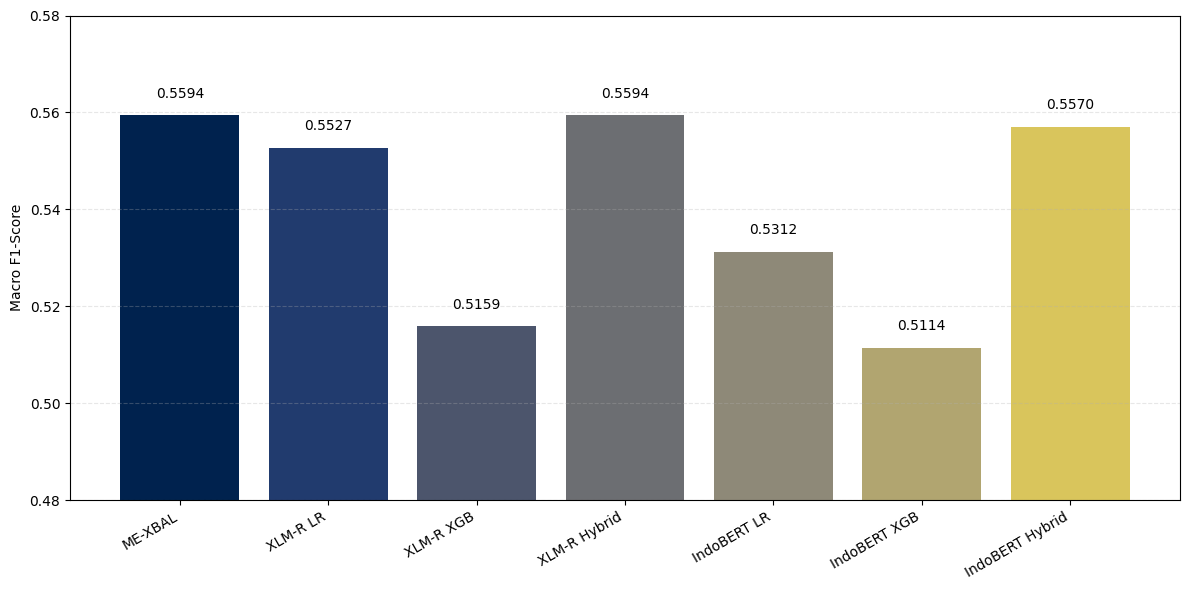

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# DATA (PAKAI HASIL YANG SUDAH ADA)
# ================================
results = {
    "ME-XBAL": 0.5594,
    "XLM-R LR": 0.5527,
    "XLM-R XGB": 0.5159,
    "XLM-R Hybrid": 0.5594,
    "IndoBERT LR": 0.5312,
    "IndoBERT XGB": 0.5114,
    "IndoBERT Hybrid": 0.5570
}

models = list(results.keys())
scores = list(results.values())

x = np.arange(len(models))

# ================================
# PLOT
# ================================
plt.figure(figsize=(12,6))

cmap = plt.cm.cividis
colors = [cmap(i/len(models)) for i in range(len(models))]

bars = plt.bar(x, scores, color=colors)

# ================================
# LABEL & TITLE
# ================================
plt.ylabel("Macro F1-Score")
# plt.title("Ablation Study on Tokopedia Dataset (Single-Label)", fontweight='bold')
plt.xticks(x, models, rotation=30, ha='right')

# ================================
# VALUE LABEL (4 DECIMAL 🔥)
# ================================
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,   # lebih dekat biar rapi
        f"{height:.4f}",  # 👈 INI KUNCINYA
        ha='center',
        va='bottom',
        fontsize=10
    )

# ================================
# GRID & LIMIT
# ================================
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0.48, 0.58)  # zoom biar beda kelihatan jelas

plt.tight_layout()
plt.show()

# Training Time Vs Inference Time Each Model

In [ ]:
# ==========================================
# ⏱️ TIME ANALYSIS (TOKOPEDIA - FULL ABLATION)
# ==========================================
import time
import numpy as np
import pandas as pd

results_time = []

# ================================
# FUNCTION: MEASURE TIME
# ================================
def measure_time(name, X_train, y_train, X_test):

    # ================================
    # TRAINING
    # ================================
    start_train = time.time()

    if name == "XLM-R LR":
        xgb_m = None
        lr_m = train_lr(X_train, y_train)

    elif name == "XLM-R XGB":
        xgb_m = train_xgb(X_train, y_train)
        lr_m = None

    elif name == "XLM-R Hybrid":
        xgb_m = train_xgb(X_train, y_train)
        lr_m = train_lr(X_train, y_train)

    elif name == "IndoBERT LR":
        xgb_m = None
        lr_m = train_lr(X_train, y_train)

    elif name == "IndoBERT XGB":
        xgb_m = train_xgb(X_train, y_train)
        lr_m = None

    elif name == "IndoBERT Hybrid":
        xgb_m = train_xgb(X_train, y_train)
        lr_m = train_lr(X_train, y_train)

    elif name == "ME-XBAL":
        xgb_m = train_xgb(X_train, y_train)
        lr_m = train_lr(X_train, y_train)

    train_time = time.time() - start_train

    # ================================
    # INFERENCE (AVERAGE)
    # ================================
    runs = 5
    times = []

    for _ in range(runs):
        start_inf = time.time()

        _ = predict(
            xgb_m,
            lr_m,
            X_test,
            ensemble=(xgb_m is not None and lr_m is not None)
        )

        times.append(time.time() - start_inf)

    inference_time = np.mean(times)

    return train_time, inference_time


# ================================
# MODEL ORDER (PENTING!)
# ================================
model_names = [
    "ME-XBAL",
    "XLM-R Hybrid",
    "XLM-R LR",
    "XLM-R XGB",
    "IndoBERT LR",
    "IndoBERT XGB",
    "IndoBERT Hybrid"
]

# ================================
# LOOP
# ================================
for name in model_names:

    print(f"⏳ Processing {name}...")

    # pilih embedding sesuai model
    if "IndoBERT" in name:
        X_train_used = X_indo_train
        X_test_used  = X_indo_test
    else:
        X_train_used = X_xlmr_train
        X_test_used  = X_xlmr_test

    train_t, inf_t = measure_time(name, X_train_used, y_train, X_test_used)

    results_time.append({
        "Model": name,
        "Training Time (s)": train_t,
        "Inference Time (s)": inf_t
    })

# ================================
# TABLE
# ================================
df_time_tokopedia = pd.DataFrame(results_time)

print("\n📊 TIME ANALYSIS (TOKOPEDIA)")
print("="*50)
display(df_time_tokopedia)

⏳ Processing ME-XBAL...
⏳ Processing XLM-R Hybrid...
⏳ Processing XLM-R LR...
⏳ Processing XLM-R XGB...
⏳ Processing IndoBERT LR...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


⏳ Processing IndoBERT XGB...
⏳ Processing IndoBERT Hybrid...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



📊 TIME ANALYSIS (TOKOPEDIA)


,Model,Training Time (s),Inference Time (s)
0,ME-XBAL,16.729905,0.040316
1,XLM-R Hybrid,14.872441,0.042095
2,XLM-R LR,2.275758,0.001779
3,XLM-R XGB,12.546469,0.014528
4,IndoBERT LR,25.278776,0.001457
5,IndoBERT XGB,11.959051,0.014293
6,IndoBERT Hybrid,31.839983,0.068406


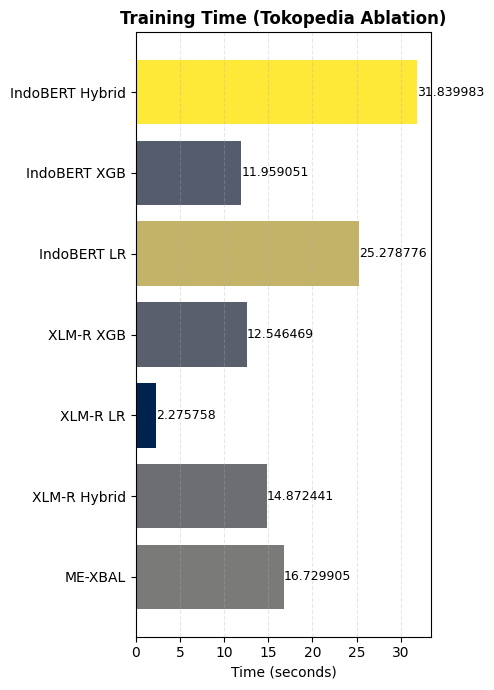

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# pastikan urutan sesuai ablation
df_plot = df_time_tokopedia.set_index("Model").loc[model_names].reset_index()

models = df_plot["Model"].values
times = df_plot["Training Time (s)"].values

cmap = plt.cm.cividis
norm = (times - times.min()) / (times.max() - times.min())
colors = [cmap(n) for n in norm]

plt.figure(figsize=(5,7))

bars = plt.barh(models, times, color=colors)

# label angka
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.0002, bar.get_y() + bar.get_height()/2,
             f"{w:.6f}", va='center', fontsize=9)

plt.xlabel("Time (seconds)")
plt.title("Training Time (Tokopedia Ablation)", fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

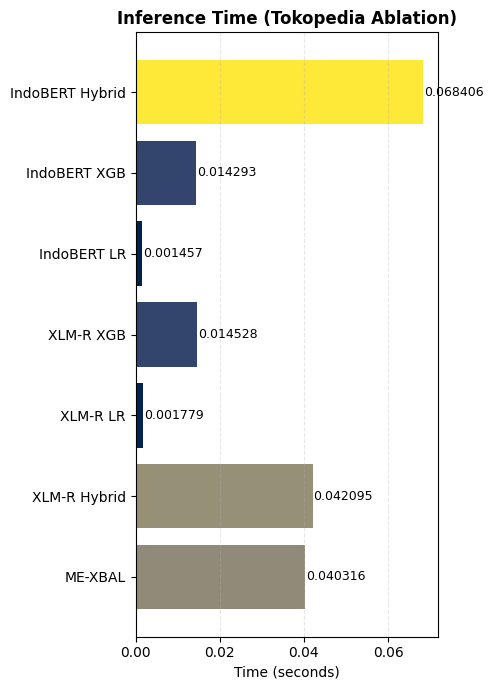

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# pastikan urutan sesuai ablation
df_plot = df_time_tokopedia.set_index("Model").loc[model_names].reset_index()

models = df_plot["Model"].values
times = df_plot["Inference Time (s)"].values

cmap = plt.cm.cividis
norm = (times - times.min()) / (times.max() - times.min())
colors = [cmap(n) for n in norm]

plt.figure(figsize=(5,7))

bars = plt.barh(models, times, color=colors)

# label angka
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.0002, bar.get_y() + bar.get_height()/2,
             f"{w:.6f}", va='center', fontsize=9)

plt.xlabel("Time (seconds)")
plt.title("Inference Time (Tokopedia Ablation)", fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()